In [13]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import img_to_array, load_img

In [14]:
path = './Dataset'
label_list = []
for dir in os.listdir(path):
    label_list.append(dir)

images = []
classes = []
for i, label in enumerate(label_list):
    full_path = os.path.join(path, label)
    for j, image in enumerate(os.listdir(full_path)):
        img_path = os.path.join(full_path, image)
        img = load_img(img_path)
        img = img_to_array(img)
        img = tf.image.rgb_to_grayscale(img)
        img = img / 255

        images.append(img)
        classes.append(i)

In [15]:
y = tf.keras.utils.to_categorical(classes, len(label_list))
images = np.asarray(images)

In [16]:
x_train, x_temp, y_train, y_temp = train_test_split(images, y, train_size=0.8, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, train_size=0.5, random_state=42)

In [25]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same', input_shape=(224, 224, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same'),
    tf.keras.layers.Conv2D(64, activation='relu', kernel_size=(3, 3), strides=(1, 1), padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(
    x_train, 
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    callbacks=early_stopping
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.4419 - loss: 1.6091 - val_accuracy: 0.6350 - val_loss: 0.8733
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.8069 - loss: 0.5425 - val_accuracy: 0.7800 - val_loss: 0.5219
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.8769 - loss: 0.3264 - val_accuracy: 0.7700 - val_loss: 0.5217
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.9237 - loss: 0.2056 - val_accuracy: 0.8250 - val_loss: 0.4387
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - accuracy: 0.9569 - loss: 0.1170 - val_accuracy: 0.8400 - val_loss: 0.5301
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.9494 - loss: 0.1499 - val_accuracy: 0.8800 - val_loss: 0.4804
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.9837 - loss: 0.0529 - val_accuracy: 0.8950 - val_loss: 0.5178


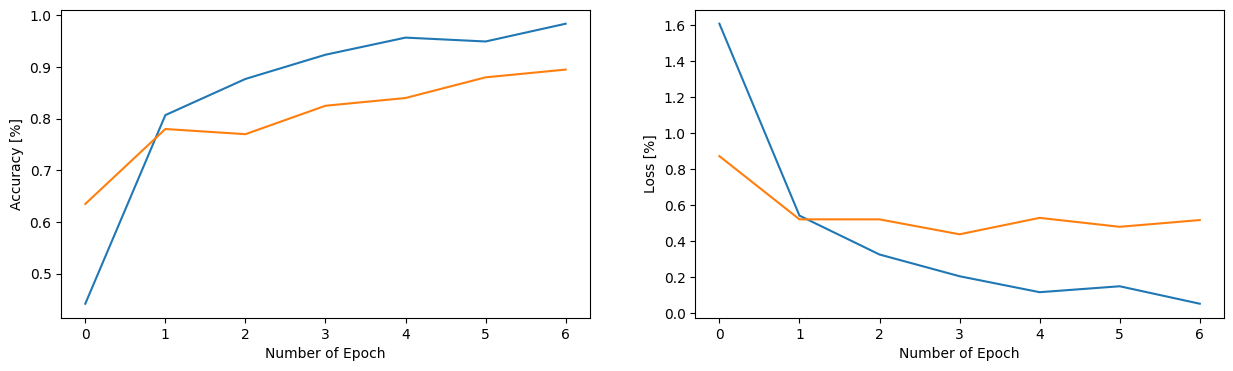

In [28]:
plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Number of Epoch')
plt.ylabel('Accuracy [%]')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Number of Epoch')
plt.ylabel('Loss [%]')

plt.show()

In [29]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f'Test Accuracy : {accuracy}')
print(f'Test Loss     : {loss}')

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true=y_true, y_pred=y_pred, target_names=label_list))

7/7 - 0s - 46ms/step - accuracy: 0.8850 - loss: 0.3341
Test Accuracy : 0.8849999904632568
Test Loss     : 0.33414149284362793
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
              precision    recall  f1-score   support

    Broccoli       0.89      0.93      0.91        54
      Carrot       0.98      0.91      0.94        53
    Cucumber       0.79      0.93      0.85        41
      Tomato       0.87      0.79      0.83        52

    accuracy                           0.89       200
   macro avg       0.88      0.89      0.88       200
weighted avg       0.89      0.89      0.89       200

